# 01. Derive ROI masks based on meta-analytic map of language from Neurosynth
This notebook shows how the ROI masks for the language regions and right hemisphere homologues were found

Inputs:
- AICHA atlas nifti
- NeuroSynth association atlas results

Steps:
1. Find significant parcels associated with language by parcellating the NeuroSynth language association results
2. Make masks of associated parcels by binarizing and smoothing.
3. Show process.

Outputs:
- 4 ROI masks (lIFG, lMTG, rIFG, and rMTG)

Written by: Jitse S. Amelink.

Last edited: 2023/10/30

### 0. import relevant functions

In [1]:
import os
from nilearn import plotting, image
from nilearn.maskers import NiftiLabelsMasker
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import nibabel as nb
import pandas as pd

#paths
work_path = "/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/mask/"

### 1. Find significant parcels associated with language based on NeuroSynth results

In [2]:
#files
yang = False
glasser = True
aicha = False

if yang:
    no_parcels = 200
    atlas_in = "/data/workspaces/lag/workspaces/lg-ukbiobank/projects/CONGRADS_rest/atlas/{}Parcels_Kong2022_17Networks_FSLMNI152_2mm.nii.gz".format(no_parcels)

if aicha:
    atlas_in = "/data/workspaces/lag/workspaces/lg-ukbiobank/projects/multilateral/FuncNet_AICHA/segs/AICHA.nii"

if glasser:
    atlas_in = "/data/workspaces/lag/workspaces/lg-ukbiobank/projects/CONGRADS_rest/atlas/MNI_Glasser_HCP_v1.0.nii.gz"


#load data
atlas_img = image.load_img(atlas_in)
lang_map = os.path.join(work_path, "language_association-test_z_FDR_0.01_231027.nii.gz")

#getting upper threshold
p_thresh = .99999999
z_thresh = st.norm.ppf(p_thresh)

# process association map
#load masker
masker = NiftiLabelsMasker(labels_img=atlas_img)

#apply mask
association_stats = masker.fit_transform(lang_map)

#threshold non-sig parcels
association_stats[association_stats < z_thresh] = 0
print(association_stats.shape)

#load image and put values in image data. i counts from 0 and atlas from 1, so i+1
association_stat_map = image.get_data(atlas_img)
for i in range(association_stats.shape[1]):
    association_stat_map[association_stat_map == i+1] = association_stats[0, i]
    
association_stat_img = image.new_img_like(atlas_img, association_stat_map, copy_header=True)

(1, 360)


### 2. Make masks of associated regions
(smoothed and binarized)

In [3]:
def make_mask(parcels, atlas_file, all_parcels, smooth_mm = 1.5, bin_thresh="50%"):
    """
    Defines mask based on parcel nos provided as input.
    Returns nifti img
    """
    #load atlas image
    atlas_img = image.load_img(atlas_file)
    
    #get data
    roi_mask = image.get_data(atlas_img)
    
    #mni_mask = image.load_img("/usr/shared/apps/fsl/6.0.3/data/standard/MNI152_T1_2mm_brain_mask.nii.gz")
    #mni_mask = image.load_img("/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/mask/fs_mask/MNI_brain_mask_tight_mask.nii.gz")
    hcp_mask = image.load_img("/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/mask/hcp_mask.nii.gz")

    
    #set parcels to 1
    print("Including parcels in mask: ", parcels)
    for i in all_parcels: # range(1, int(no_parcels+1), 1):
        if i in parcels:
            roi_mask[roi_mask == i] = np.array([1])
        else:
            roi_mask[roi_mask == i] = 0
    
    #return image
    roi_mask_img = image.new_img_like(atlas_img, roi_mask, copy_header=True)
    
    #smooth image
    #roi_mask_img = image.smooth_img(roi_mask_img, smooth_mm)
    
    #return binarized image
    return image.binarize_img(roi_mask_img, threshold=bin_thresh, mask_img=hcp_mask)

In [4]:
sig_parcels = np.where(association_stats)[1]
print(sig_parcels)

[ 73  74  75  78  80  81 124 127 128 129 138]


In [5]:
if yang:
    #load LUT
    lut_file = "/data/workspaces/lag/workspaces/lg-ukbiobank/projects/CONGRADS_rest/atlas/{}Parcels_Kong2022_17Networks_LUT.txt".format(no_parcels)
    parcel_df = pd.read_csv(lut_file, sep = "\s+|\t+|\s+\t+|\t+\s+", header=None, names="Parcel_no R G B Network_region".split())

    #get left hemisphere parcels with significance (everything below 200)
    sig_parcels = [x+1 for x in sig_parcels[sig_parcels < 200]]

    # read names
    parcel_df_sig = parcel_df[parcel_df["Parcel_no"].isin(sig_parcels)]

    # cluster in temp and PFC"
    l_mtg = []
    for anat_term in ["Temp", "ST"]:
        l_mtg += list(parcel_df_sig[parcel_df_sig["Network_region"].str.contains(anat_term)]["Parcel_no"].values)
    l_mtg = sorted(l_mtg)
    l_temp_set = set(l_mtg)
    l_ifg = [x for x in sig_parcels if x not in l_temp_set]

    #get right hemisphere homologues
    lr_diff = int(no_parcels/2)
    r_mtg = [int(x)+lr_diff for x in l_mtg]
    r_ifg = [int(x)+lr_diff for x in l_ifg]
    
if glasser:
    #sig_parcels = [x+1 for x in sig_parcels[sig_parcels < 200]]
    
    l_ifg = [x+1 for x in sig_parcels[sig_parcels < 100]]
    l_mtg = [x+1 for x in sig_parcels[sig_parcels > 100][:-1]]
    print(l_ifg)
    print(l_mtg)
    
    r_ifg = [x + 1000 for x in l_ifg]
    r_mtg = [x + 1000 for x in l_mtg]
    
if aicha:
    l_ifg = [x + 1 for x in sig_parcels[:3]]
    l_mtg = [x + 1 for x in sig_parcels[3:]]
    r_ifg = [x + 1 for x in l_ifg]
    r_mtg = [x + 1 for x in l_mtg]
    

[74, 75, 76, 79, 81, 82]
[125, 128, 129, 130]


In [6]:
if glasser:
    all_parcels = list(range(1, 181, 1))
    all_parcels = all_parcels + [x+1000 for x in all_parcels]
if aicha:
    all_parcels = list(range(1, 385, 1))
if yang:
    all_parcels = list(range(1, no_parcels+1, 1))

In [7]:
#make masks
l_ifg_mask = make_mask(parcels = l_ifg, atlas_file = atlas_in, smooth_mm = 0, bin_thresh = "50%", all_parcels = all_parcels)
l_mtg_mask = make_mask(parcels = l_mtg, atlas_file = atlas_in, smooth_mm = 0, bin_thresh = "50%", all_parcels = all_parcels)
r_ifg_mask = make_mask(parcels = r_ifg, atlas_file = atlas_in, smooth_mm = 0, bin_thresh = "50%", all_parcels = all_parcels)
r_mtg_mask = make_mask(parcels = r_mtg, atlas_file = atlas_in, smooth_mm = 0, bin_thresh = "50%", all_parcels = all_parcels)

#save masks
save=True
if save:
    l_ifg_mask.to_filename(os.path.join(work_path, "roi_lifg_glasser.nii.gz")) #.format(no_parcels, p_thresh)))
    l_mtg_mask.to_filename(os.path.join(work_path, "roi_lmtg_glasser.nii.gz")) #.format(no_parcels, p_thresh)))
    r_ifg_mask.to_filename(os.path.join(work_path, "roi_rifg_glasser.nii.gz")) #.format(no_parcels, p_thresh)))
    r_mtg_mask.to_filename(os.path.join(work_path, "roi_rmtg_glasser.nii.gz")) #.format(no_parcels, p_thresh)))

Including parcels in mask:  [74, 75, 76, 79, 81, 82]


/home/jitame/bin/anaconda3/envs/results_env/lib/python3.10/site-packages/nilearn/image/image.py:1041: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  return new_img_like(niimg, result, niimg.affine)


Including parcels in mask:  [125, 128, 129, 130]
Including parcels in mask:  [1074, 1075, 1076, 1079, 1081, 1082]
Including parcels in mask:  [1125, 1128, 1129, 1130]


### 3. Visualize process

/home/jitame/bin/anaconda3/envs/results_env/lib/python3.10/site-packages/nilearn/plotting/displays/_slicers.py:382: UserWarning: empty mask
  get_mask_bounds(new_img_like(img, not_mask, affine))


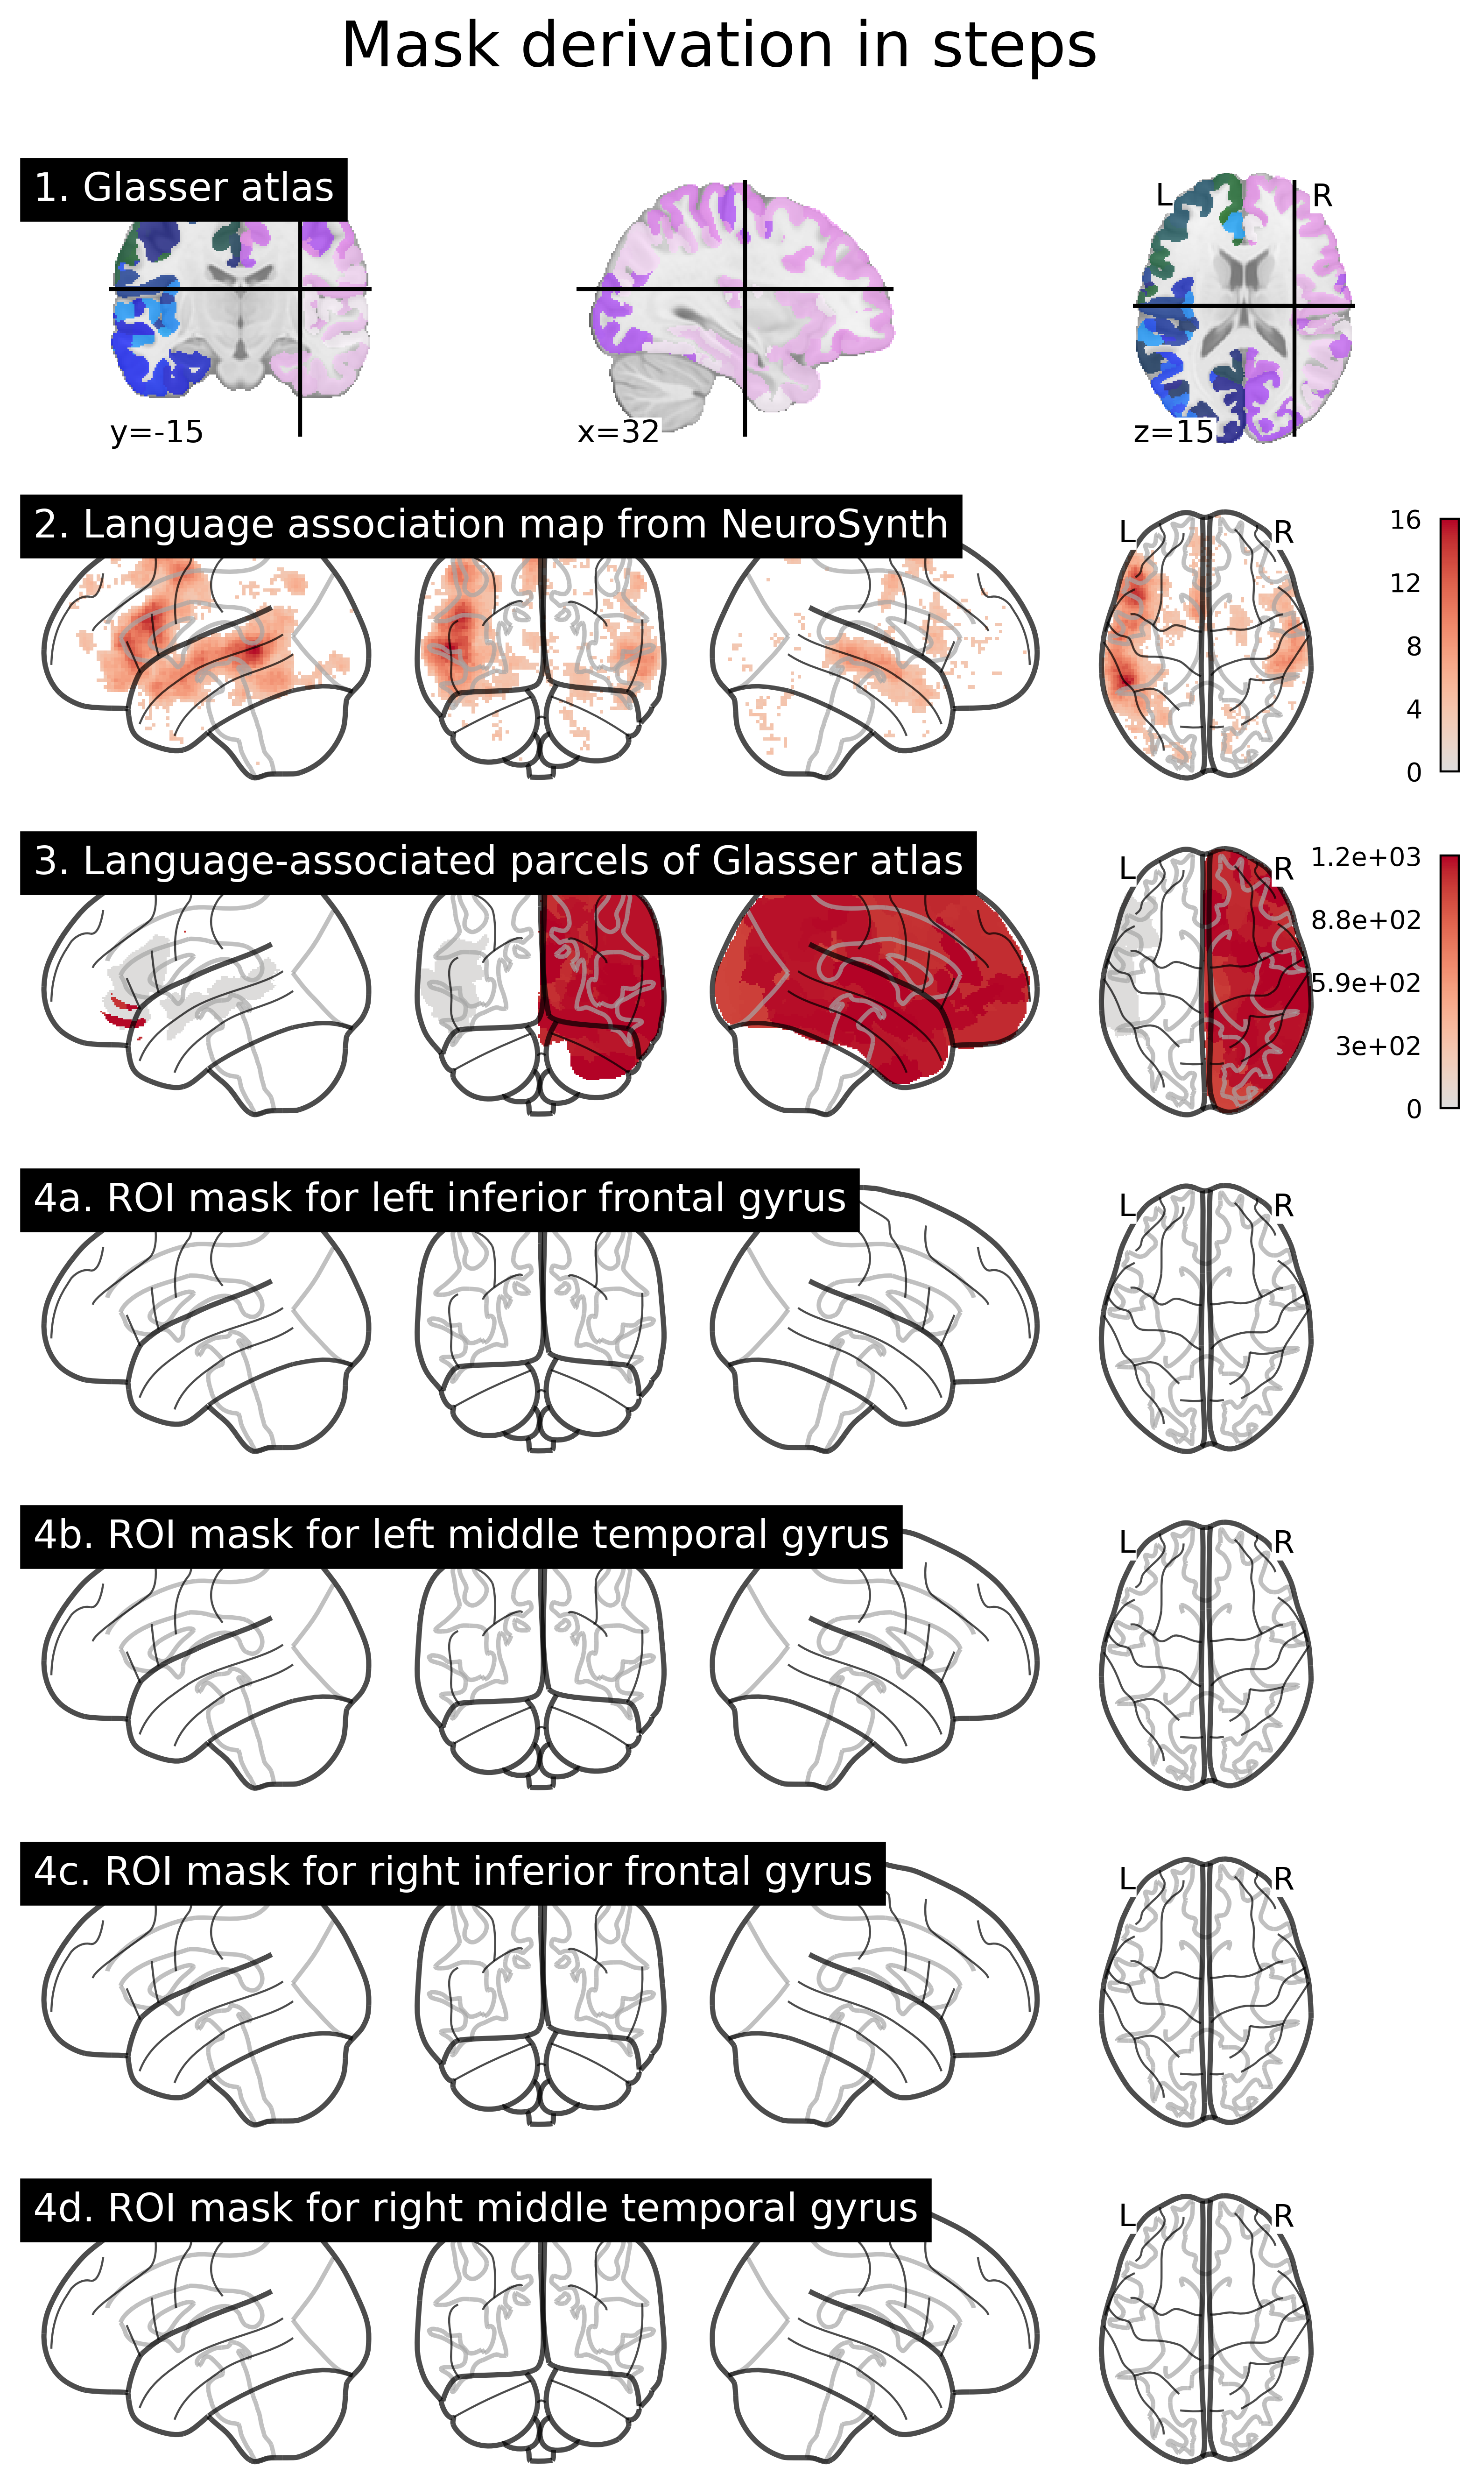

In [8]:
#explain process in figures
fig_args = {"figsize":(10,16),"dpi":400}

fig, ax = plt.subplots(7, 1, gridspec_kw={'height_ratios': [1]*7}, **fig_args)

fig.suptitle("Mask derivation in steps", y=0.93, fontsize=24)

plotting.plot_roi(image.load_img(atlas_in), title="1. Glasser atlas", axes=ax[0])
plotting.plot_glass_brain(image.load_img(lang_map), display_mode='lyrz', colorbar=True, cmap='coolwarm',
                                        title="2. Language association map from NeuroSynth", axes=ax[1])
plotting.plot_glass_brain(association_stat_img, display_mode='lyrz', colorbar=True, cmap='coolwarm', plot_abs=False,
                                        title="3. Language-associated parcels of Glasser atlas", axes=ax[2])
plotting.plot_glass_brain(l_ifg_mask, display_mode='lyrz', colorbar=True, cmap='coolwarm', plot_abs=False,
                                        title="4a. ROI mask for left inferior frontal gyrus", axes=ax[3])
plotting.plot_glass_brain(l_mtg_mask, display_mode='lyrz', colorbar=True, cmap='coolwarm', plot_abs=False,
                                        title="4b. ROI mask for left middle temporal gyrus", axes=ax[4])
plotting.plot_glass_brain(r_ifg_mask, display_mode='lyrz', colorbar=True, cmap='coolwarm', plot_abs=False,
                                        title="4c. ROI mask for right inferior frontal gyrus", axes=ax[5])
plotting.plot_glass_brain(r_mtg_mask, display_mode='lyrz', colorbar=True, cmap='coolwarm', plot_abs=False,
                                        title="4d. ROI mask for right middle temporal gyrus", axes=ax[6])
plt.savefig(fname="/data/workspaces/lag/workspaces/lg-ukbiobank/projects/CONGRADS_rest/results/mask_derivation_glasser.png", bbox_inches="tight")